In [3]:
import pandas as pd

In [4]:
algorithms = [
    ["线性回归", "监督学习", "回归", "预测连续数值", "房价预测、销量预测"],
    ["逻辑回归", "监督学习", "分类", "二分类问题", "是否患病、是否流失"],
    ["KNN", "监督学习", "分类/回归", "根据邻居投票", "小数据分类、相似样本判断"],
    ["朴素贝叶斯", "监督学习", "分类", "基于概率分类", "文本分类、垃圾邮件识别"],
    ["决策树", "监督学习", "分类/回归", "用规则做判断", "可解释建模"],
    ["随机森林", "监督学习", "分类/回归", "多棵树集成", "表格数据、分类预测"],
    ["SVM", "监督学习", "分类/回归", "寻找最大间隔边界", "小中型分类任务"],
    ["GBDT", "监督学习", "分类/回归", "不断修正前面模型的错误", "结构化数据预测"],
    ["XGBoost", "监督学习", "分类/回归", "工程增强版 GBDT", "比赛、工业建模"],
    ["LightGBM", "监督学习", "分类/回归", "高效快速的提升树", "大规模表格数据"],
    ["KMeans", "无监督学习", "聚类", "自动分组", "用户分群、样本聚类"],
    ["Isolation Forest", "异常检测", "异常检测", "孤立异常点", "欺诈检测、故障检测"],
    ["时间序列特征工程", "时间序列", "预测", "用历史预测未来", "销量预测、指标预测"]
]

df_algorithms = pd.DataFrame(
    algorithms,
    columns=["算法", "大类", "任务类型", "核心思想", "典型应用"]
)

df_algorithms

,算法,大类,任务类型,核心思想,典型应用
0,线性回归,监督学习,回归,预测连续数值,房价预测、销量预测
1,逻辑回归,监督学习,分类,二分类问题,是否患病、是否流失
2,KNN,监督学习,分类/回归,根据邻居投票,小数据分类、相似样本判断
3,朴素贝叶斯,监督学习,分类,基于概率分类,文本分类、垃圾邮件识别
4,决策树,监督学习,分类/回归,用规则做判断,可解释建模
5,随机森林,监督学习,分类/回归,多棵树集成,表格数据、分类预测
6,SVM,监督学习,分类/回归,寻找最大间隔边界,小中型分类任务
7,GBDT,监督学习,分类/回归,不断修正前面模型的错误,结构化数据预测
8,XGBoost,监督学习,分类/回归,工程增强版 GBDT,比赛、工业建模
9,LightGBM,监督学习,分类/回归,高效快速的提升树,大规模表格数据


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [6]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X 形状：", X.shape)
print("y 形状：", y.shape)
print("类别名称：", data.target_names)

X 形状： (569, 30)
y 形状： (569,)
类别名称： ['malignant' 'benign']


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "GBDT": GradientBoostingClassifier(random_state=42)
}

In [8]:
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )
    
    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

df_results = pd.DataFrame(
    results,
    columns=["模型", "平均准确率", "标准差"]
)

df_results = df_results.sort_values(
    by="平均准确率",
    ascending=False
)

df_results

,模型,平均准确率,标准差
6,GBDT,0.963127,0.021024
4,Random Forest,0.956094,0.022839
0,Logistic Regression,0.950800,0.018041
2,Naive Bayes,0.938519,0.014586
1,KNN,0.927946,0.021763
3,Decision Tree,0.917342,0.024195
5,SVM,0.912172,0.035444


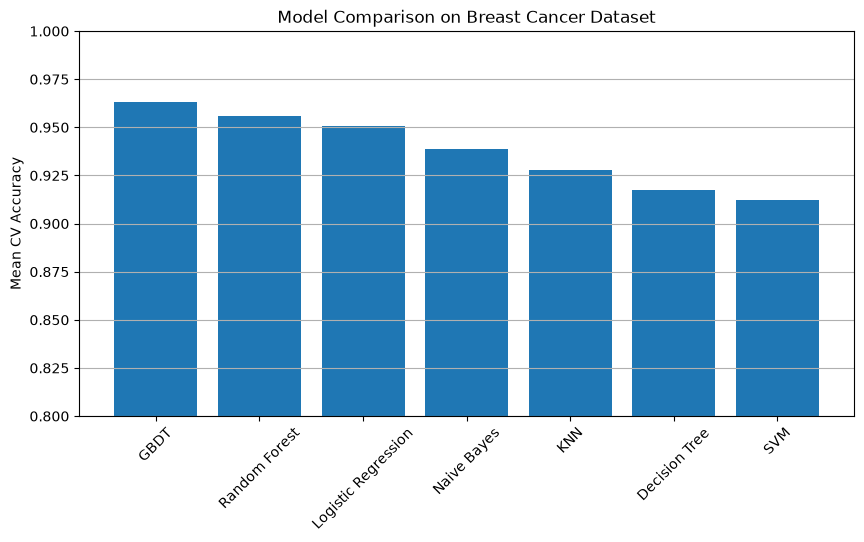

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(df_results["模型"], df_results["平均准确率"])
plt.ylabel("Mean CV Accuracy")
plt.title("Model Comparison on Breast Cancer Dataset")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.grid(axis="y")
plt.show()